## Librerias

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from sklearn.metrics import roc_auc_score
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns  
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap



## Carga datos clean

In [3]:
df_ops = pd.read_csv('C:\\Users\\Usuario\\ProjecteData\\Equip_25\\Data\\clean_data_24-03-2026.csv', parse_dates=['insert_date'])

# inventario activo
df_active = df_ops.loc[df_ops["has_availability"] == True, ["apartment_id","host_id", "room_type", "bedrooms", "bathrooms", "beds", "accommodates", 
                                                            "availability_30", "availability_60", "availability_90", "availability_365", "minimum_nights", 
                                                            "maximum_nights", "city",
                                                            "insert_date", "is_instant_bookable", "price", "price_missing"]].copy()

df_active.info()
df_active.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9116 entries, 0 to 9649
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   apartment_id         9116 non-null   int64         
 1   host_id              9116 non-null   int64         
 2   room_type            9116 non-null   object        
 3   bedrooms             9048 non-null   float64       
 4   bathrooms            9043 non-null   float64       
 5   beds                 9072 non-null   float64       
 6   accommodates         9116 non-null   int64         
 7   availability_30      9116 non-null   int64         
 8   availability_60      9116 non-null   int64         
 9   availability_90      9116 non-null   int64         
 10  availability_365     9116 non-null   int64         
 11  minimum_nights       9116 non-null   int64         
 12  maximum_nights       9116 non-null   int64         
 13  city                 9116 non-null   o

,apartment_id,host_id,room_type,bedrooms,bathrooms,beds,accommodates,availability_30,availability_60,availability_90,availability_365,minimum_nights,maximum_nights,city,insert_date,is_instant_bookable,price,price_missing
0,11964,45553,Private room,1.0,2.0,1.0,2,7,20,40,130,3,365,Malaga,2018-07-31,False,400.0,False
1,21853,83531,Private room,1.0,1.0,1.0,1,0,0,0,162,4,40,Madrid,2020-01-10,False,170.0,False
2,32347,139939,Entire home/apt,2.0,1.0,2.0,4,26,31,31,270,2,120,Sevilla,2019-07-29,True,990.0,False
3,35379,152232,Private room,1.0,2.0,1.0,2,9,23,49,300,2,730,Barcelona,2020-01-10,True,400.0,False
4,35801,153805,Private room,2.0,1.0,5.0,5,0,19,49,312,1,180,Girona,2019-02-19,False,900.0,False


In [4]:
# host_counts = df_active.groupby("host_id")["apartment_id"].nunique()

# host_counts.describe()
# host_counts.value_counts().head(10)

In [5]:
RUTA_FIGURES = Path(r"C:\Users\Usuario\Desktop\PROYECTO")

def guardar_grafico(fig, nombre_archivo, formato="png", dpi=300):
    RUTA_FIGURES.mkdir(parents=True, exist_ok=True)

    ruta_archivo = RUTA_FIGURES / f"{nombre_archivo}.{formato}"

    fig.savefig(ruta_archivo, bbox_inches="tight", dpi=dpi)
    plt.close(fig)

    print(f"Gráfico guardado en: {ruta_archivo}")

#### Definición de métricas
- Disponibilidad: Normalizas horizontes temporales, permite comparabilidad, availability_30 captura demanda reciente
- Capacidad total: bedrooms no captura sofás cama, etc., accommodates es la capacidad real de demanda
- Densidad: listings sobrecargados vs cómodos
- Tamaño categorizado (para interpretación): mejora la lectura de resultados

In [6]:
# precio en nulos
df_active['price_filled'] = df_active['price'].fillna(df_active['price'].median())

# precio por persona
df_active['price_per_guest'] = df_active['price_filled'] / df_active['accommodates']

# LOG TRANSFORM -- para manejar la asimetría del precio por persona por existencia de listings con precios muy altos
df_active['log_price_per_guest'] = np.log(df_active['price_per_guest'])

# disponibilidad
df_active['availability_30_pct'] = df_active['availability_30'] / 30
df_active['availability_60_pct'] = df_active['availability_60'] / 60
df_active['availability_90_pct'] = df_active['availability_90'] / 90
df_active['availability_365_pct'] = df_active['availability_365'] / 365

available_cols = ["availability_30_pct", "availability_60_pct", "availability_90_pct", "availability_365_pct"]

# habitaciones
df_active['bedrooms'] = df_active['bedrooms'].fillna(0)
# baños
df_active['bathrooms'] = pd.to_numeric(df_active['bathrooms'], errors='coerce')
# camas
df_active['beds'] = df_active['beds'].fillna(0)

# capacidad total
df_active['capacity'] = df_active['accommodates']

# densidad
df_active['bed_density'] = df_active['beds'] / df_active['accommodates']

# tamaño categorizado
df_active['size_segment'] = pd.cut(
    df_active['accommodates'],
    bins=[0,2,4,6,10,20],
    labels=['1-2','3-4','5-6','7-10','10+']
)

# bed density
df_active['bed_density'] = df_active['beds'] / df_active['accommodates']

In [7]:
columns_needed = [
    'availability_30_pct',
    'capacity',
    'size_segment',
    'bed_density',
    'bathrooms',
    'price_per_guest',
    'log_price_per_guest',
    'city',
    'room_type'
]

df_model = df_active[columns_needed].dropna().copy()

## Análisis / visualizaciones
Com afecta el nombre d'habitacions, banys i llits
disponibles a la disponibilitat mitjana dels allotjaments? Difereix entre ciutats?

In [8]:
# Media simple
df_model.groupby('capacity')['availability_30_pct'].mean()

capacity
1     0.416621
2     0.406754
3     0.411761
4     0.440157
5     0.448285
6     0.453155
7     0.425667
8     0.475115
9     0.457407
10    0.484422
11    0.510000
12    0.556180
13    0.814286
14    0.541667
15    0.700000
16    0.596212
18    1.000000
19    1.000000
20    0.000000
Name: availability_30_pct, dtype: float64

In [9]:
# Por ciudad
df_model.groupby(['city','size_segment'])['availability_30_pct'].mean()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\3481323032.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model.groupby(['city','size_segment'])['availability_30_pct'].mean()


city       size_segment
Barcelona  1-2             0.403630
           3-4             0.401719
           5-6             0.424015
           7-10            0.428319
           10+             0.560000
Girona     1-2             0.503672
           3-4             0.496549
           5-6             0.498410
           7-10            0.465820
           10+             0.597484
Madrid     1-2             0.367304
           3-4             0.386197
           5-6             0.422690
           7-10            0.489333
           10+             0.696667
Malaga     1-2             0.387816
           3-4             0.452713
           5-6             0.405051
           7-10            0.427928
           10+             0.700000
Mallorca   1-2             0.502513
           3-4             0.418868
           5-6             0.446195
           7-10            0.476368
           10+             0.517808
Menorca    1-2             0.441667
           3-4             0.503876
    

In [10]:
df_active[['bedrooms','beds','accommodates']].corr()

,bedrooms,beds,accommodates
bedrooms,1.000000,0.774495,0.796162
beds,0.774495,1.000000,0.861774
accommodates,0.796162,0.861774,1.000000


Se confirma multicolinealidad entre variables --> accommodates como variable de capacidad (capacity) y creación de  bed_density para representar configuración del espacio por persona

#### Modelo logit

In [11]:
# 1. Filtrado
df_model = df_model[df_model['capacity'] < 15]      # eliminar alojamientos con capacidad excesiva
df_model = df_model[df_model['bed_density'] < 2]    # eliminar alojamientos con densidad de camas excesiva (ej. 10 camas para 2 huéspedes)

# 2. Crear target binario
df_model['low_occupancy'] = (df_model['availability_30_pct'] > 0.6).astype(int)     # transformar disponibilidad en variable binaria: 1 si disponibilidad > 60%, 0 si no

# 3. Seleccionar variables
X = df_model[['capacity', 'bed_density', 'bathrooms', 'city', 'room_type', 'log_price_per_guest']]      # lo que explica
y = df_model['low_occupancy']                                                                           # lo que quiero explicar 

# 4. Dummies
X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)     # convertir variables categóricas en binarias, eliminando la primera categoría para evitar multicolinealidad

# 5. Numérico
X = X.astype(float)     # asegurar que todas las variables son numéricas para el modelo logit

# 6. Limpiar NaNs
df_model_final = pd.concat([X, y], axis=1).dropna()     # unir X e y en un solo df y eliminar filas con valores NaN

# 7. Recuperar X e Y limpios
X = df_model_final.drop(columns=['low_occupancy'])
y = df_model_final['low_occupancy']

# 8. Añadir constante
X = sm.add_constant(X)      # tener un punto base para el modelo. No forzar el intercepto a 0, sino permitir que el modelo lo estime

# 9. Entrenar modelo logit
logit_model = sm.Logit(y, X).fit()      # encuentra la relación entre las variables explicativas y la probabilidad de que un alojamiento tenga baja ocupación (disponibilidad > 50%)

print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.649485
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          low_occupancy   No. Observations:                 8945
Model:                          Logit   Df Residuals:                     8930
Method:                           MLE   Df Model:                           14
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.01873
Time:                        10:47:29   Log-Likelihood:                -5809.6
converged:                       True   LL-Null:                       -5920.5
Covariance Type:            nonrobust   LLR p-value:                 1.857e-39
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.6734      0.255    -10.471      0.000      -3.174      

In [29]:
# 1. Filtrado
df_model = df_model[df_model['capacity'] < 15]      # eliminar alojamientos con capacidad excesiva
df_model = df_model[df_model['bed_density'] < 2]    # eliminar alojamientos con densidad de camas excesiva (ej. 10 camas para 2 huéspedes)

# 2. Crear target binario
df_model['high_dispo'] = (df_model['availability_30_pct'] > 0.4).astype(int)     # transformar disponibilidad en variable binaria: 1 si disponibilidad > 40%, 0 si no

# 3. Seleccionar variables
X = df_model[['capacity', 'bed_density', 'bathrooms', 'city', 'room_type', 'log_price_per_guest']]      # lo que explica
y = df_model['high_dispo']                                                                           # lo que quiero explicar 

# 4. Dummies
X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)     # convertir variables categóricas en binarias, eliminando la primera categoría para evitar multicolinealidad

# 5. Numérico
X = X.astype(float)     # asegurar que todas las variables son numéricas para el modelo logit

# 6. Limpiar NaNs
df_model_final2 = pd.concat([X, y], axis=1).dropna()     # unir X e y en un solo df y eliminar filas con valores NaN

# 7. Recuperar X e Y limpios
X = df_model_final2.drop(columns=['high_dispo'])
y = df_model_final2['high_dispo']

# 8. Añadir constante
X = sm.add_constant(X)      # tener un punto base para el modelo. No forzar el intercepto a 0, sino permitir que el modelo lo estime

# 9. Entrenar modelo logit
logit_model2 = sm.Logit(y, X).fit()      # encuentra la relación entre las variables explicativas y la probabilidad de que un alojamiento tenga baja ocupación (disponibilidad > 50%)

print(logit_model2.summary())


Optimization terminated successfully.
         Current function value: 0.682754
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_dispo   No. Observations:                 8324
Model:                          Logit   Df Residuals:                     8309
Method:                           MLE   Df Model:                           14
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.01259
Time:                        10:48:06   Log-Likelihood:                -5683.2
converged:                       True   LL-Null:                       -5755.7
Covariance Type:            nonrobust   LLR p-value:                 7.594e-24
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.2541      0.300     -7.501      0.000      -2.843      

In [13]:
p30 = df_model['availability_30_pct'].quantile(0.3)
p70 = df_model['availability_30_pct'].quantile(0.7)
df_model_pct = df_model[
    (df_model['availability_30_pct'] <= p30) |
    (df_model['availability_30_pct'] >= p70)
].copy()
df_model_pct['low_occupancy'] = (
    df_model_pct['availability_30_pct'] >= p70
).astype(int)
X = df_model_pct[['capacity', 'bed_density', 'bathrooms', 'city', 'room_type', 'log_price_per_guest']]
y = df_model_pct['low_occupancy']

# dummies
X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)

# numérico
X = X.astype(float)

# limpiar NaNs
df_model_final = pd.concat([X, y], axis=1).dropna()

X = df_model_final.drop(columns=['low_occupancy'])
y = df_model_final['low_occupancy']

X = sm.add_constant(X)

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

y_pred = logit_model.predict(X)

auc = roc_auc_score(y, y_pred)
print("AUC:", auc)

Optimization terminated successfully.
         Current function value: 0.679730
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          low_occupancy   No. Observations:                 5698
Model:                          Logit   Df Residuals:                     5683
Method:                           MLE   Df Model:                           14
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.01932
Time:                        10:47:30   Log-Likelihood:                -3873.1
converged:                       True   LL-Null:                       -3949.4
Covariance Type:            nonrobust   LLR p-value:                 2.152e-25
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.0931      0.303     -6.912      0.000      -2.687      

El modelo muestra que la capacidad del alojamiento tiene un efecto positivo 
y significativo sobre la disponibilidad, lo que indica que los alojamientos 
más grandes tienden a tener menor ocupación relativa.

El precio por huésped también presenta un efecto positivo significativo, 
sugiriendo que alojamientos más caros tienden a estar más disponibles.

Por el contrario, variables como el número de baños y la densidad de camas 
no resultan significativas, lo que indica que la configuración interna del 
alojamiento tiene un impacto limitado una vez controlamos por el tamaño.

Asimismo, se observan diferencias relevantes entre ciudades y tipos de 
alojamiento, lo que refleja la existencia de patrones de demanda distintos 
según localización y tipo de oferta.

Sin embargo, el bajo R² indica que las variables estructurales explican 
solo una pequeña parte de la variabilidad, por lo que otros factores de 
demanda no incluidos en el modelo juegan un papel importante.

## Resultados / archivos generados

In [14]:
colores = ['darkseagreen','khaki','powderblue','darkgoldenrod','darkgray','darkolivegreen','lightslategray','lightgray']

cmap_custom = LinearSegmentedColormap.from_list(
    "custom_palette",
    ['powderblue','khaki', 'darkseagreen']
)

#### Distribución general de disponibilidad

Existen diferencias estructurales entre ciudades en los niveles de disponibilidad, lo que sugiere que la demanda no es homogénea geográficamente.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\734088208.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


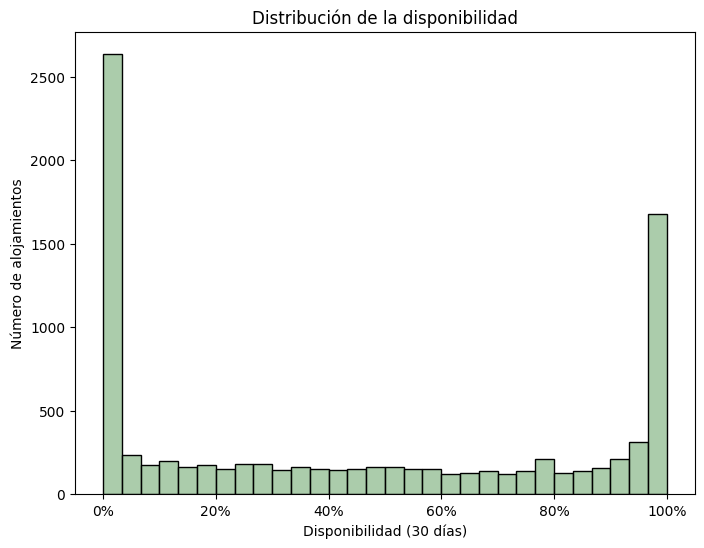

In [15]:
fig,ax = plt.subplots(figsize=(8,6))
sns.histplot(df_model['availability_30_pct'], bins=30, color='darkseagreen')
plt.title("Distribución de la disponibilidad")
plt.xlabel("Disponibilidad (30 días)")
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.ylabel("Número de alojamientos")
fig.show()
#guardar_grafico(fig, "distribucion_disponibilidad")
df_model['availability_pct'] = df_model['availability_30_pct'] * 100

# bins
bins = np.linspace(0, 100, 21)

hist, bin_edges = np.histogram(df_model['availability_pct'], bins=bins)

df_hist = pd.DataFrame({
    'bin_start': bin_edges[:-1],
    'bin_end': bin_edges[1:],
    'count': hist
})
df_hist['bin_label'] = df_hist['bin_start'].astype(int).astype(str) + '-' + df_hist['bin_end'].astype(int).astype(str)

df_hist.to_csv(RUTA_FIGURES / "histograma_disponibilidad.csv", index=False)

#### Capacidad

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\2475566243.py:1: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(


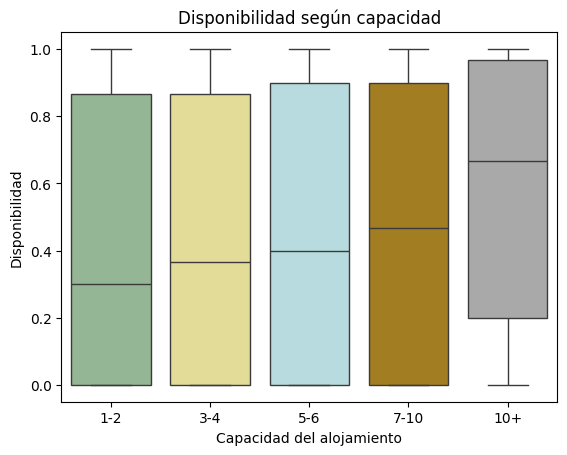

In [16]:
sns.boxplot(
    x='size_segment',
    y='availability_30_pct',
    data=df_active,
    hue='size_segment',
    palette=colores,
    legend=False
)
plt.title("Disponibilidad según capacidad")
plt.xlabel("Capacidad del alojamiento")
plt.ylabel("Disponibilidad")
plt.show()

#### Por precio

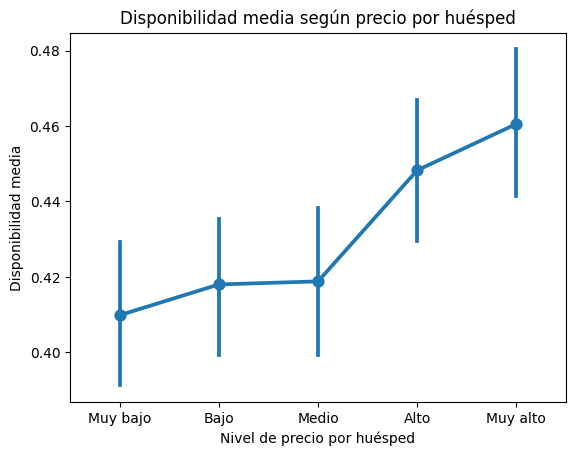

In [17]:
df_model = df_model[df_model['price_per_guest'] < 500]
df_model['price_group'] = pd.qcut(df_model['price_per_guest'], 5)
df_model['price_group'] = pd.qcut(
    df_model['price_per_guest'],
    5,
    labels=['Muy bajo','Bajo','Medio','Alto','Muy alto']
)
sns.pointplot(
    x='price_group',
    y='availability_30_pct',
    data=df_model
)

plt.title("Disponibilidad media según precio por huésped")
plt.xlabel("Nivel de precio por huésped")
plt.ylabel("Disponibilidad media")

plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\958329011.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price = df_model.groupby('price_group').agg(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\958329011.py:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


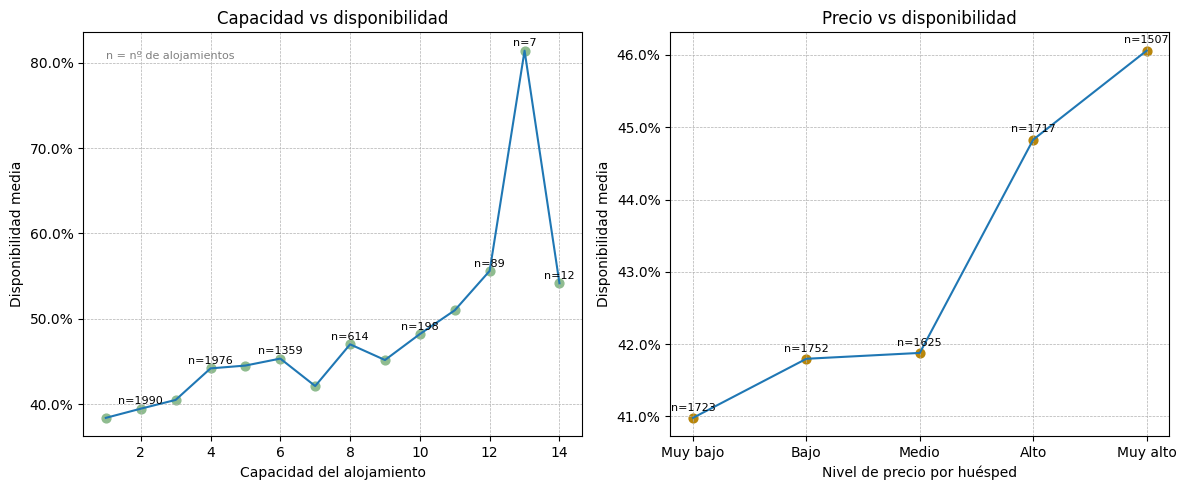

In [18]:
# CAPACITY
df_cap = df_model.groupby('capacity').agg(
    availability_30_pct=('availability_30_pct', 'mean'),
    n=('capacity', 'size')
).reset_index()

# PRICE GROUP
df_price = df_model.groupby('price_group').agg(
    availability_30_pct=('availability_30_pct', 'mean'),
    n=('price_group', 'size')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -------- CAPACITY --------
sns.lineplot(
    data=df_cap,
    x='capacity',
    y='availability_30_pct',
    ax=axes[0],
    errorbar=None
)
# scatter (puntos visibles)
axes[0].scatter(
    df_cap['capacity'],
    df_cap['availability_30_pct'],
    color='darkseagreen',
    s=40
)

for _, row in df_cap.iterrows():
    if row['capacity'] in [2,4,6,8,10,12,13,14]:
        axes[0].text(
            row['capacity'],
            row['availability_30_pct'] + 0.005,
            f"n={int(row['n'])}",
            ha='center',
            fontsize=8
        )

axes[0].set_title("Capacidad vs disponibilidad")
axes[0].set_xlabel("Capacidad del alojamiento")
axes[0].set_ylabel("Disponibilidad media")

# -------- PRICE --------
sns.lineplot(
    data=df_price,
    x='price_group',
    y='availability_30_pct',
    ax=axes[1],
    errorbar=None
)

axes[1].scatter(
    df_price['price_group'],
    df_price['availability_30_pct'],
    color='darkgoldenrod',
    s=40
)

for _, row in df_price.iterrows():
    axes[1].text(
        row['price_group'],
        row['availability_30_pct'] + 0.001,
        f"n={int(row['n'])}",
        ha='center',
        fontsize=8
        )
axes[1].set_title("Precio vs disponibilidad")
axes[1].set_xlabel("Nivel de precio por huésped")
axes[1].set_ylabel("Disponibilidad media")

import matplotlib.ticker as mtick

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[0].text(
    1,
    0.805,
    "n = nº de alojamientos",
    fontsize=8,
    color='gray'
)

fig.tight_layout()
fig.show()

#guardar_grafico(fig, "capacidad_precio_vs_disponibilidad")

El precio por huésped muestra una relación positiva con la disponibilidad, lo que sugiere que precios más elevados pueden estar asociados a menor demanda relativa o a estrategias de pricing menos competitivas.

#### Por ciudad

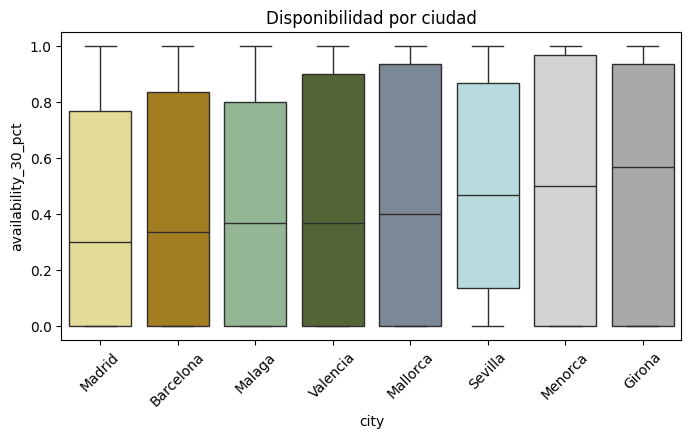

In [19]:
order = df_active.groupby('city')['availability_30_pct'].median().sort_values().index

plt.figure(figsize=(8,4))
sns.boxplot(
    x='city',
    y='availability_30_pct',
    hue='city',
    data=df_active,
    palette=colores,
    order=order,
)
plt.title("Disponibilidad por ciudad")
plt.xticks(rotation=45)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\2486548293.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_active.pivot_table(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\2486548293.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


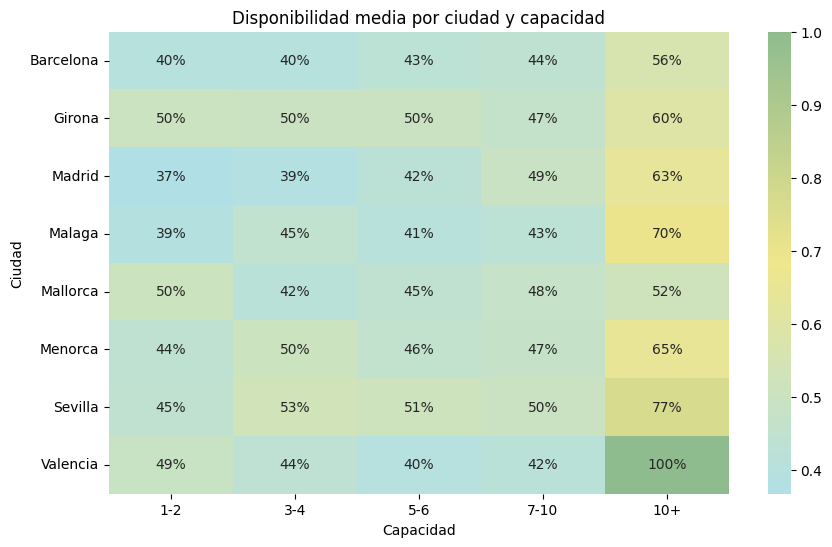

In [20]:
pivot = df_active.pivot_table(
    values='availability_30_pct',
    index='city',
    columns='size_segment',
    aggfunc='mean'
)
labels = (pivot * 100).round(0).astype(int).astype(str) + "%"
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=labels,
    fmt="",
    cmap=cmap_custom
)

ax.set_title("Disponibilidad media por ciudad y capacidad")
ax.set_xlabel("Capacidad")
ax.set_ylabel("Ciudad")

fig.show()
#guardar_grafico(fig, "ciudad_capacidad_vs_disponibilidad")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\4102189843.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_pivot = df_active.pivot_table(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\4102189843.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


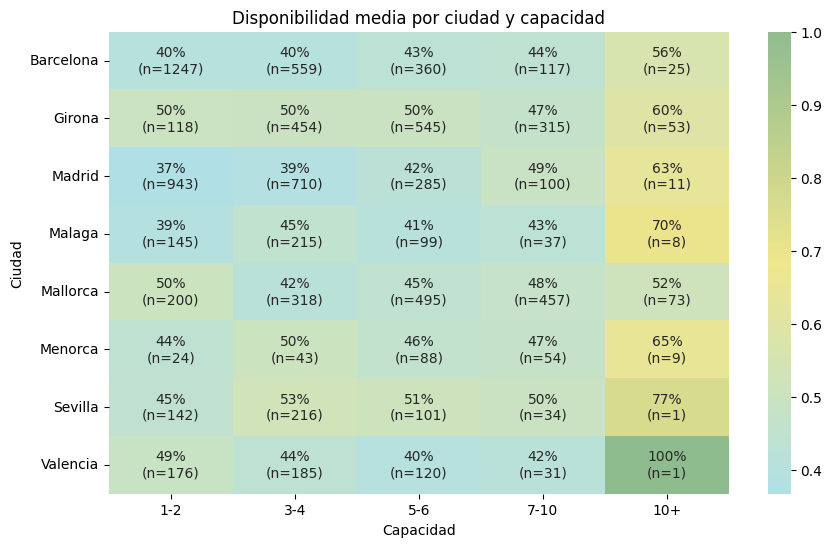

In [21]:
count_pivot = df_active.pivot_table(
    values='availability_30_pct',
    index='city',
    columns='size_segment',
    aggfunc='count'
)

annot_matrix = pivot.copy().astype(str)

for i in pivot.index:
    for j in pivot.columns:
        value = pivot.loc[i, j]
        count = count_pivot.loc[i, j]
        
        annot_matrix.loc[i, j] = f"{value:.0%}\n(n={count})"
fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=annot_matrix,
    fmt="",
    cmap=cmap_custom
)

ax.set_title("Disponibilidad media por ciudad y capacidad")
ax.set_xlabel("Capacidad")
ax.set_ylabel("Ciudad")

fig.show()
#guardar_grafico(fig, "ciudad_capacidad_vs_disponibilidad2")

El mercado está segmentado entre alojamientos con alta ocupación y otros con baja ocupación, lo que sugiere comportamientos muy distintos entre listings.

#### Explicación del modelo

In [22]:
def asignar_color(nombre):
    if 'Capacity' in nombre:
        return 'darkseagreen'
    elif 'Price' in nombre:
        return 'darkgoldenrod'
    elif 'Bathroom' in nombre or 'Bed Density' in nombre:
        return 'darkgray'
    elif 'Tipo' in nombre:
        return 'lightslategray'
    elif 'Ciudad' in nombre:
        return 'powderblue'
    else:
        return 'lightgray'


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\3401783617.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


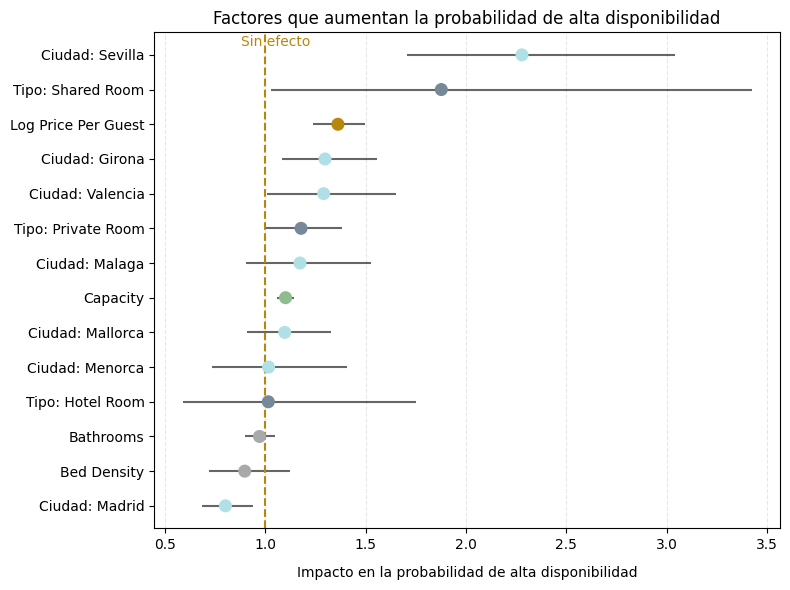

In [23]:
coef = logit_model.params
conf = logit_model.conf_int()

odds = np.exp(coef)
conf_low = np.exp(conf[0])
conf_high = np.exp(conf[1])

df_odds = pd.DataFrame({
    'odds_ratio': odds,
    'conf_low': conf_low,
    'conf_high': conf_high
}).drop('const')

# ordenar
df_odds = df_odds.sort_values(by='odds_ratio')

# limpiar nombres
df_odds.index = df_odds.index.str.replace('city_', 'Ciudad: ')
df_odds.index = df_odds.index.str.replace('room_type_', 'Tipo: ')
df_odds.index = df_odds.index.str.replace('_', ' ')
df_odds.index = df_odds.index.str.title()

# colores
colors = [asignar_color(idx) for idx in df_odds.index]

# -------- PLOT --------
fig, ax = plt.subplots(figsize=(8,6))

# intervalos (sin punto)
ax.errorbar(
    df_odds['odds_ratio'],
    df_odds.index,
    xerr=[df_odds['odds_ratio'] - df_odds['conf_low'],
          df_odds['conf_high'] - df_odds['odds_ratio']],
    fmt='none',
    ecolor='black',
    alpha=0.6
)

# puntos
ax.scatter(
    df_odds['odds_ratio'],
    df_odds.index,
    c=colors,
    s=70,
    zorder=3
)

# línea referencia
ax.axvline(1, linestyle='--', color='darkgoldenrod', linewidth=1.5)

# etiquetas eje
ax.set_xlabel("Impacto en la probabilidad de alta disponibilidad", labelpad=10)
ax.set_title("Factores que aumentan la probabilidad de alta disponibilidad")

# texto "sin efecto" alineado
ax.text(
    1.05,
    len(df_odds)-0.75,
    'Sin efecto',
    color='darkgoldenrod',
    ha='center',
    fontsize=10
)

# eliminar ruido visual innecesario
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)

plt.tight_layout()
fig.show()
# guardar_grafico(fig, "factores_influencia_baja_ocupacion")

In [ ]:
coef = logit_model2.params
conf = logit_model2.conf_int()

odds = np.exp(coef)
conf_low = np.exp(conf[0])
conf_high = np.exp(conf[1])

df_odds = pd.DataFrame({
    'odds_ratio': odds,
    'conf_low': conf_low,
    'conf_high': conf_high
}).drop('const')

# ordenar
df_odds = df_odds.sort_values(by='odds_ratio')

# limpiar nombres
df_odds.index = df_odds.index.str.replace('city_', 'Ciudad: ')
df_odds.index = df_odds.index.str.replace('room_type_', 'Tipo: ')
df_odds.index = df_odds.index.str.replace('_', ' ')
df_odds.index = df_odds.index.str.title()

# colores
colors = [asignar_color(idx) for idx in df_odds.index]

# -------- PLOT --------
fig, ax = plt.subplots(figsize=(8,6))

# intervalos (sin punto)
ax.errorbar(
    df_odds['odds_ratio'],
    df_odds.index,
    xerr=[df_odds['odds_ratio'] - df_odds['conf_low'],
          df_odds['conf_high'] - df_odds['odds_ratio']],
    fmt='none',
    ecolor='black',
    alpha=0.6
)

# puntos
ax.scatter(
    df_odds['odds_ratio'],
    df_odds.index,
    c=colors,
    s=70,
    zorder=3
)

# línea referencia
ax.axvline(1, linestyle='--', color='darkgoldenrod', linewidth=1.5)

# etiquetas eje
ax.set_xlabel("Impacto en la probabilidad de alta disponibilidad", labelpad=10)
ax.set_title("Factores que aumentan la probabilidad de alta disponibilidad")

# texto "sin efecto" alineado
ax.text(
    1.05,
    len(df_odds)-0.75,
    'Sin efecto',
    color='darkgoldenrod',
    ha='center',
    fontsize=10
)

# eliminar ruido visual innecesario
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)

plt.tight_layout()
fig.show()
#guardar_grafico(fig, "factores_influencia_baja_ocupacion_new")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\3956767246.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Gráfico guardado en: C:\Users\Usuario\Desktop\PROYECTO\factores_influencia_baja_ocupacion_new.png


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26404\3201226725.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


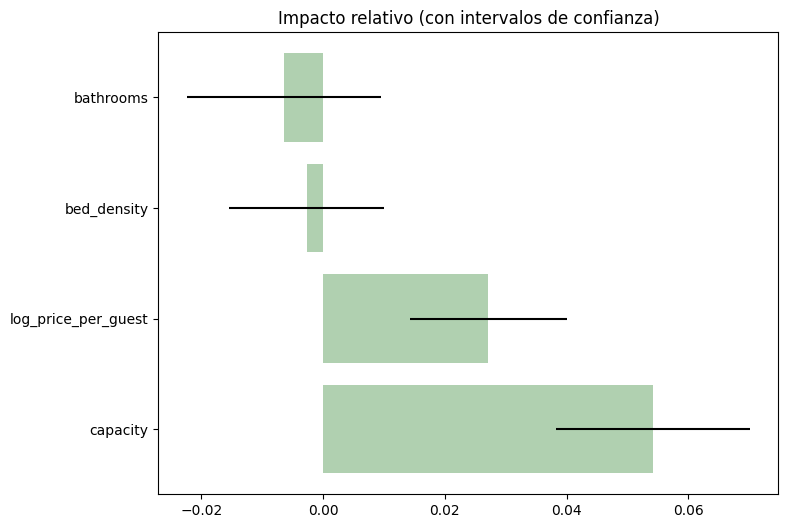

In [24]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

features = ['capacity', 'log_price_per_guest', 'bed_density', 'bathrooms']

# unificar y limpiar
df_combined = pd.concat(
    [df_model[features], df_model_pct['availability_30_pct']],
    axis=1
).dropna()

X = df_combined[features]
y = df_combined['availability_30_pct']

# estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)

# modelo
X_scaled = sm.add_constant(X_scaled)
model = sm.OLS(y, X_scaled).fit()

# coeficientes
coefs = model.params.drop('const')

# coefs.sort_values().plot(kind='barh')
# plt.title('Impacto relativo de variables (estandarizadas)')
conf = model.conf_int().loc[coefs.index]

fig, ax = plt.subplots(figsize=(8,6))
plt.barh(coefs.index, coefs.values, xerr=(conf[1] - conf[0]) / 2, color='darkseagreen', alpha=0.7)
ax.set_title('Impacto relativo (con intervalos de confianza)')

fig.show()
#guardar_grafico(fig, "impacto_relativo_variables_estandarizadas")

✔️ Variables estructurales

capacity → sí influye (positivo)

price → sí influye (positivo)

bathrooms → no

bed_density → no

✔️ Variables de control (muy importantes)

ciudades → diferencias claras

tipo de alojamiento → impacto fuerte

Las variables estructurales relacionadas con el tamaño del alojamiento influyen en la disponibilidad, mientras que la configuración interna tiene un impacto limitado. Además, factores como la ciudad o el tipo de alojamiento presentan efectos más relevantes.

#### Info extra

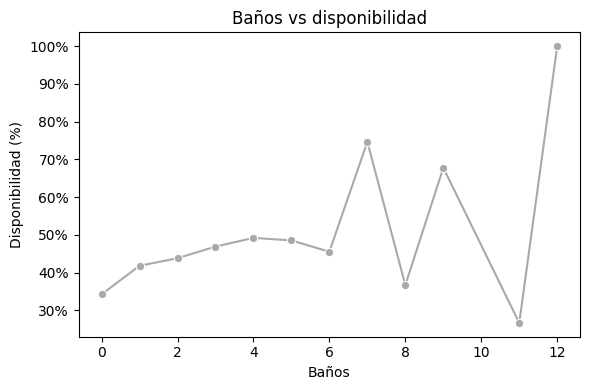

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# agrupar por bathrooms
bathroom_group = df_model.groupby('bathrooms')['availability_30_pct'].mean().reset_index()

plt.figure(figsize=(6,4))

sns.lineplot(
    data=bathroom_group,
    x='bathrooms',
    y='availability_30_pct',
    marker='o',
    color='darkgray',
    errorbar=None  # sin "aura"
)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.xlabel("Baños")
plt.ylabel("Disponibilidad (%)")
plt.title("Baños vs disponibilidad")

plt.tight_layout()
plt.show()

In [26]:
import statsmodels.formula.api as smf

model = smf.ols(
    'availability_30_pct ~ capacity + bed_density + bathrooms + log_price_per_guest + capacity:bed_density',
    data=df_model
).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     availability_30_pct   R-squared:                       0.009
Model:                             OLS   Adj. R-squared:                  0.009
Method:                  Least Squares   F-statistic:                     15.76
Date:                 Wed, 08 Apr 2026   Prob (F-statistic):           1.76e-15
Time:                         10:47:35   Log-Likelihood:                -4032.8
No. Observations:                 8324   AIC:                             8078.
Df Residuals:                     8318   BIC:                             8120.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             

<Axes: >

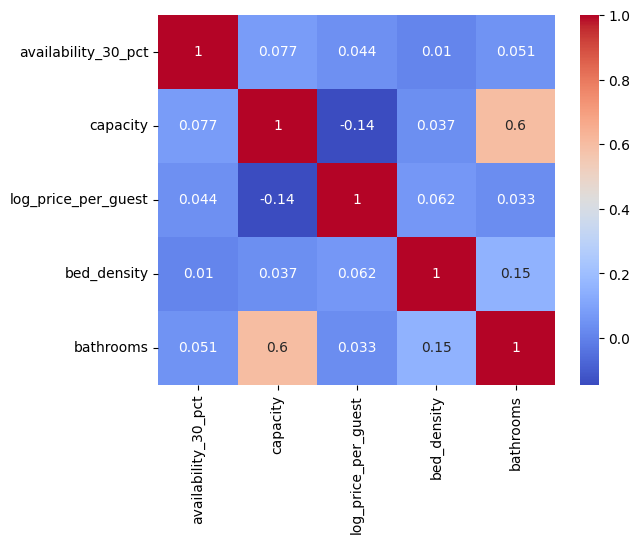

In [27]:
import seaborn as sns

corr = df_model[['availability_30_pct','capacity','log_price_per_guest','bed_density','bathrooms']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='bed_density', ylabel='availability_30_pct'>

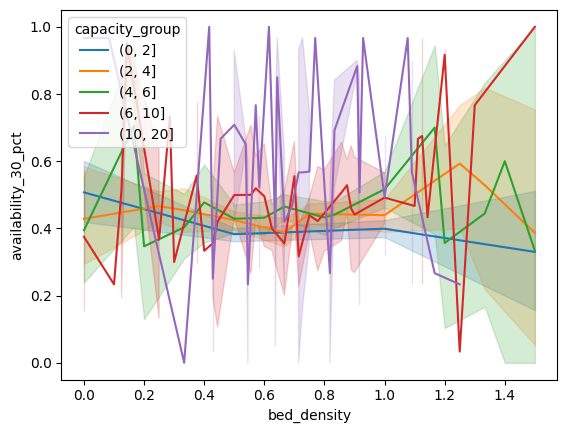

In [28]:
import seaborn as sns

# agrupar capacidad
df_model['capacity_group'] = pd.cut(df_model['capacity'], bins=[0,2,4,6,10,20])

sns.lineplot(
    data=df_model,
    x='bed_density',
    y='availability_30_pct',
    hue='capacity_group',
    estimator='mean'
)

#### Conclusiones generales

La disponibilidad de los alojamientos muestra una distribución polarizada, 
con una parte importante de listings altamente ocupados y otros con baja ocupación.

El análisis por capacidad indica que los alojamientos más grandes tienden a 
presentar mayor disponibilidad, lo que sugiere una menor ocupación relativa.

Asimismo, se observan diferencias entre ciudades, lo que refleja una demanda 
heterogénea en función del contexto geográfico.

El modelo de regresión captura estas tendencias generales, aunque presenta una 
capacidad limitada para predecir la disponibilidad individual, lo que indica 
la existencia de factores relevantes no incluidos en el análisis.